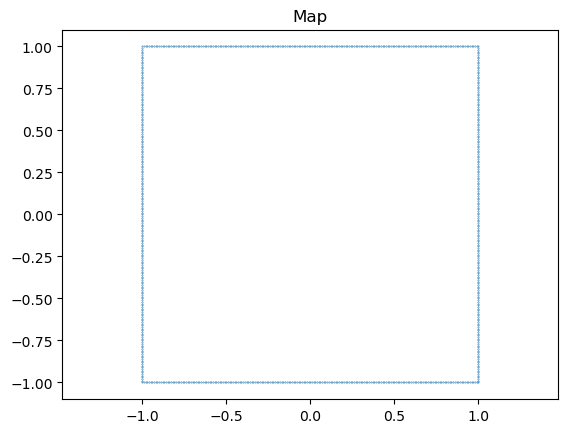

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# Create a fake map (2x2 meter empty square, with 1mm resolution)
simulation_map = []
# North wall
simulation_map.extend([[x, -1] for x in np.arange(-1, 1, 0.01)])
# East wall
simulation_map.extend([[1, y] for y in np.arange(-1, 1, 0.01)])
# South wall
simulation_map.extend([[x, 1] for x in np.arange(1, -1, -0.01)])
# West wall
simulation_map.extend([[-1, y] for y in np.arange(1, -1, -0.01)])
simulation_map = np.array(simulation_map)

# Plot the map
plt.figure()
plt.scatter(simulation_map[:, 0], simulation_map[:, 1], s=0.1)
plt.axis('equal')
plt.title('Map')
plt.show()

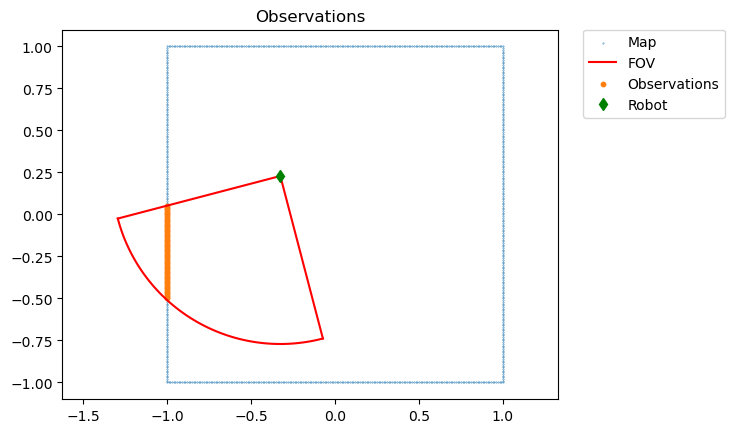

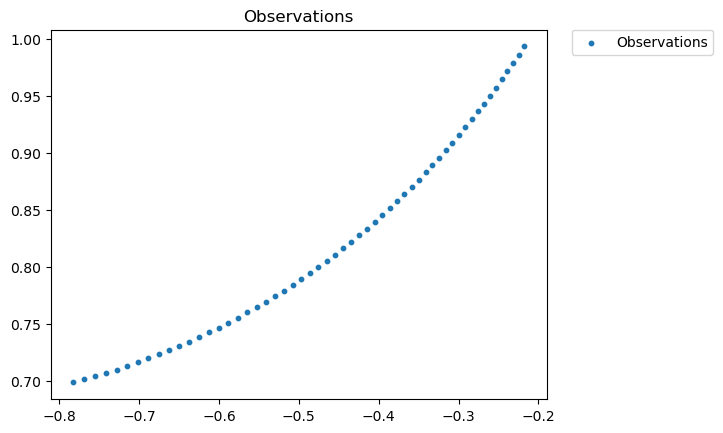

-0.3248179 0.22909425


In [2]:
# Create a function that, given a position and a map, returns the range and bearing of
# the edges of the map, assuming a FOV of 90 degrees, a maximum range of 1 meter and
# a total of 90 measurements.
def get_observations(robot_pose, simulation_map, fov, max_range):
    """Get the observations from the robot pose and the map.

    Parameters
    ----------
    robot_pose : numpy array
        The robot pose as (x, y, gamma).
    map : numpy array
        The map as an array of (x, y) points.

    Returns
    -------
    numpy array
        The observations as an array of (range, bearing) points.
    """
    # Get the robot pose
    robot_x = robot_pose[0]
    robot_y = robot_pose[1]
    robot_gamma = robot_pose[2]
    # Get the map points
    map_x = simulation_map[:, 0]
    map_y = simulation_map[:, 1]
    # Calculate the range and bearing
    range_obs = np.linalg.norm(simulation_map - robot_pose[0:2], axis=1)
    bearing = np.arctan2(map_y - robot_y, map_x - robot_x) - robot_gamma
    # Bearing should be +/- np.pi
    bearing = (bearing + np.pi) % (2 * np.pi) - np.pi
    observations = np.array([range_obs, bearing])
    # Filter the observations
    observations = observations[:, (observations[0] < max_range) & (observations[1] < fov / 2) & (observations[1] > -fov / 2)]
    # Return the observations
    return observations.T

# Test the function
robot_pose = np.array([-0.3248179, 0.22909425, 4.18318531]) #np.array([0.5, 0.2, 1.2])
fov = np.pi / 2
range_max = 1.0

# Generate observations
observations = get_observations(robot_pose, simulation_map, fov, range_max)

# Plot the FOV
fov_points = np.array(
    [
        [range_max * np.cos(fov / 2 + robot_pose[2]), range_max * np.sin(fov / 2 + robot_pose[2])],
        [0, 0],
        [range_max * np.cos(-fov / 2 + robot_pose[2]), range_max * np.sin(-fov / 2 + robot_pose[2])],
    ]
)
fov_points = fov_points + robot_pose[0:2]
# Add a semicircle
t = np.linspace(- fov / 2+ robot_pose[2], fov / 2+ robot_pose[2], 100)
x = range_max * np.cos(t) + robot_pose[0]
y = range_max * np.sin(t) + robot_pose[1]

# Plot the observations
plt.figure()
plt.scatter(simulation_map[:, 0], simulation_map[:, 1], s=0.1, label='Map')
plt.plot(x, y, c="r")
plt.plot(fov_points[:, 0], fov_points[:, 1], c="r", label="FOV")
plt.scatter(robot_pose[0] + observations[:, 0] * np.cos(observations[:, 1] + robot_pose[2]),
            robot_pose[1] + observations[:, 0] * np.sin(observations[:, 1] + robot_pose[2]), s=10, label='Observations')
plt.plot(robot_pose[0], robot_pose[1], 'gd', label='Robot')
plt.axis('equal')
plt.title('Observations')
# Place legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

plt.figure()
plt.scatter(observations[:, 1], observations[:, 0], s=10, label='Observations')
plt.title('Observations')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

print(robot_pose[0], robot_pose[1])


Step 0
Number of effective particles:  50.000000000000036


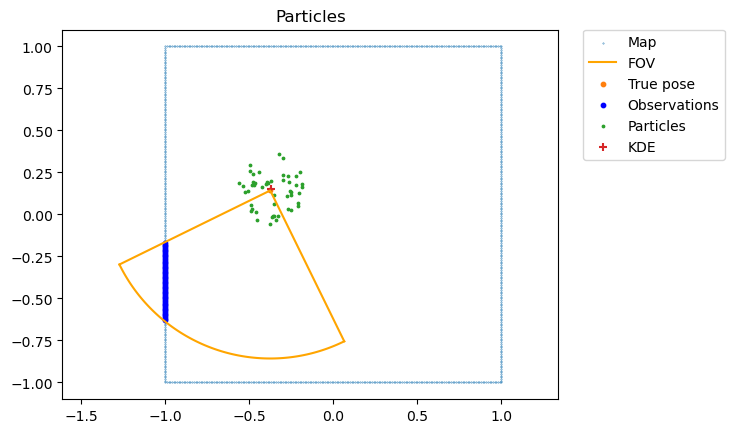

Step 1
Number of effective particles:  50.00000000000013


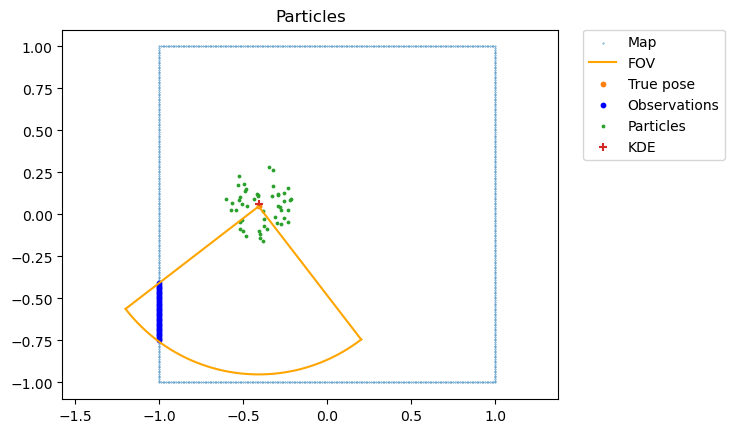

Step 2
Number of effective particles:  50.000000000000036


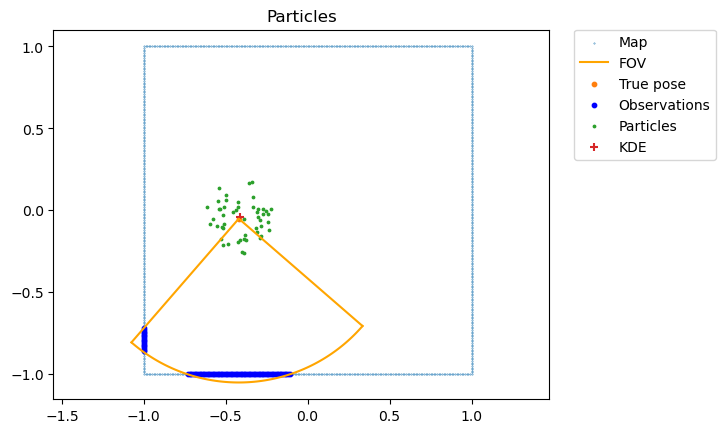

Step 3
Number of effective particles:  50.00000000000013


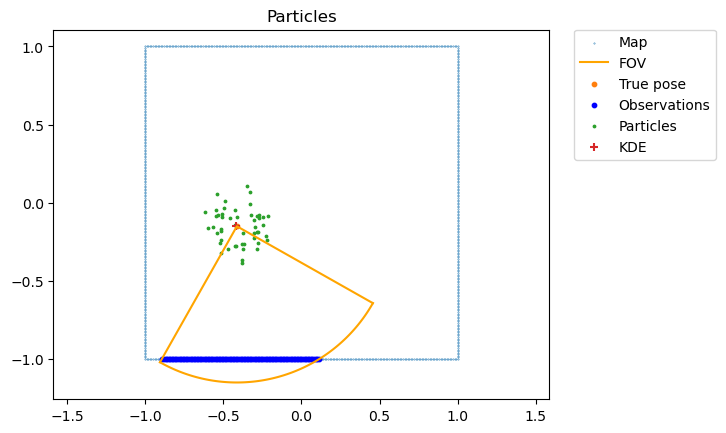

Step 4
Number of effective particles:  50.000000000000036


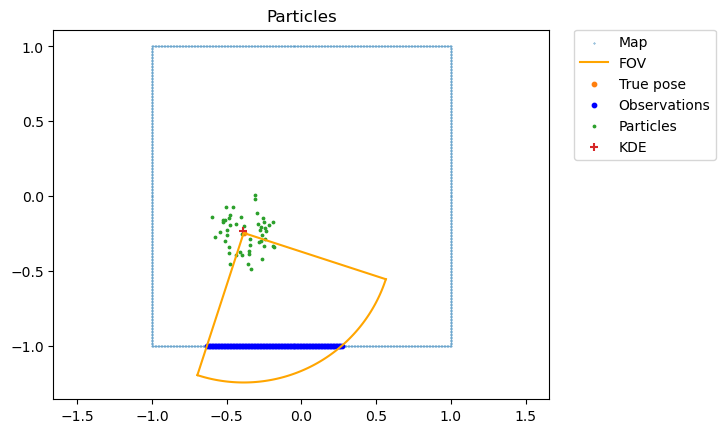

Step 5
Number of effective particles:  50.00000000000013


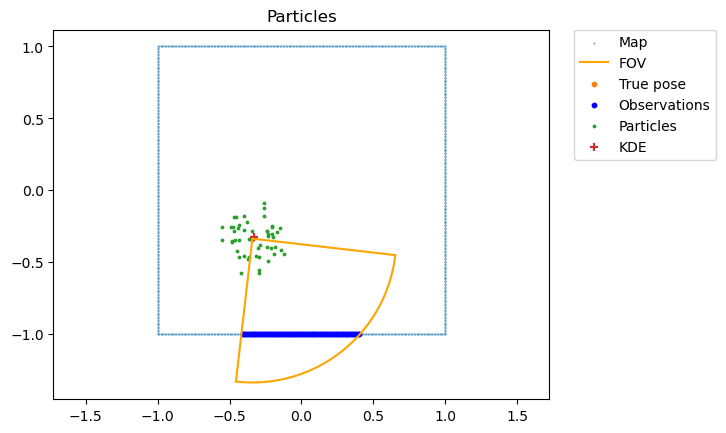

Step 6
Number of effective particles:  50.000000000000036


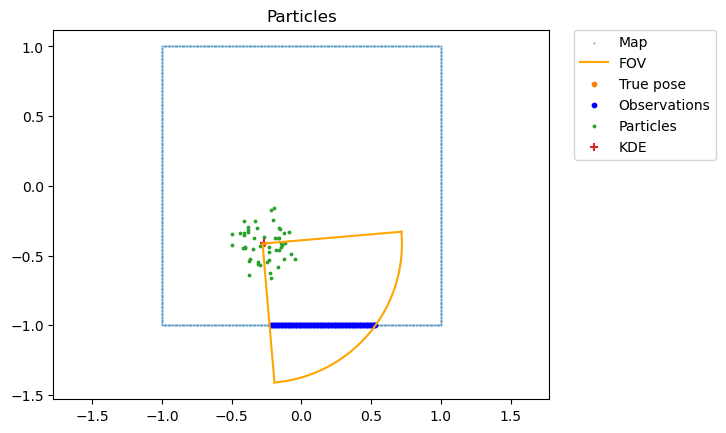

Step 7
Number of effective particles:  50.00000000000013


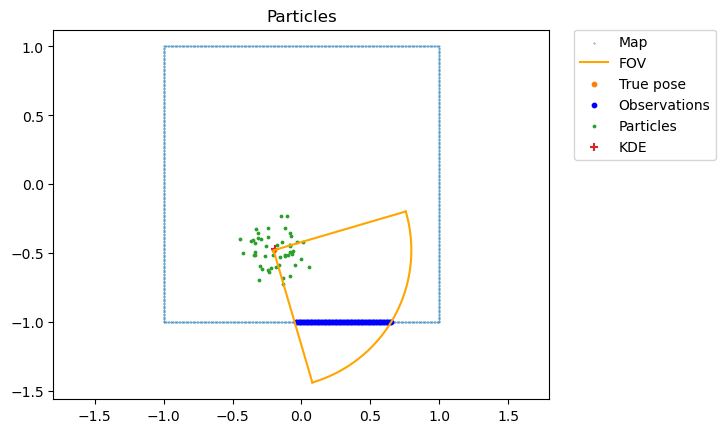

Step 8
Number of effective particles:  50.000000000000036


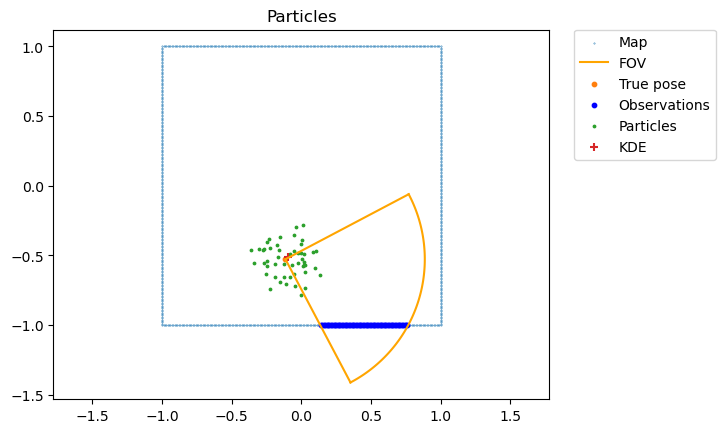

Step 9
Number of effective particles:  49.06276328373221


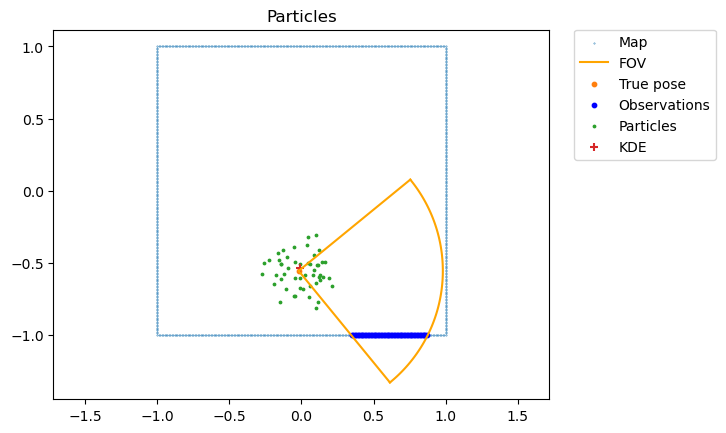

Step 10
Number of effective particles:  3.6105853036727065
Resampling


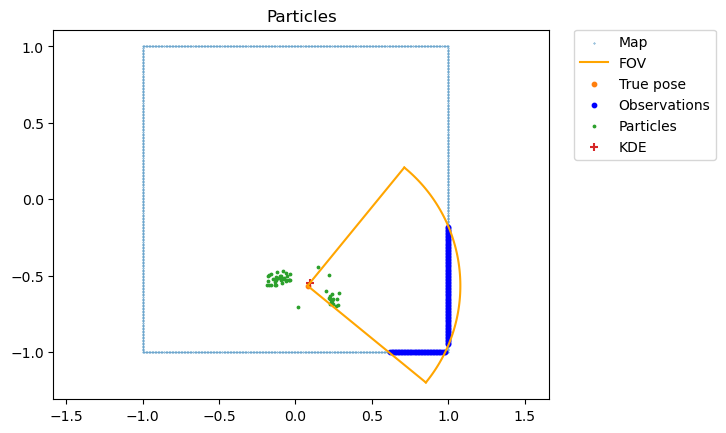

Step 11
Number of effective particles:  43.96495019612286


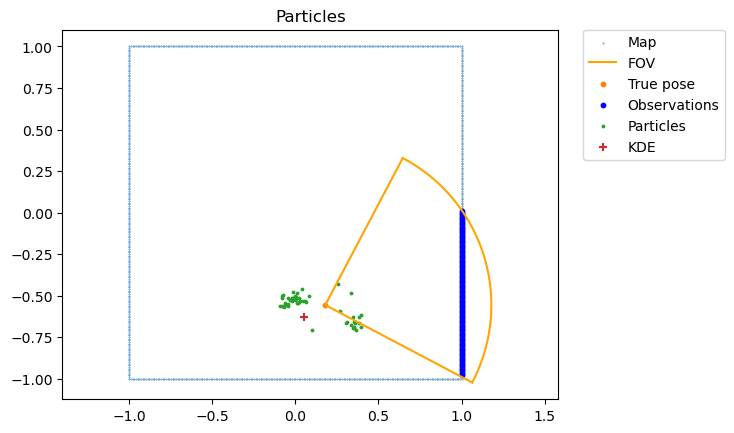

Step 12
Number of effective particles:  43.433012782406664


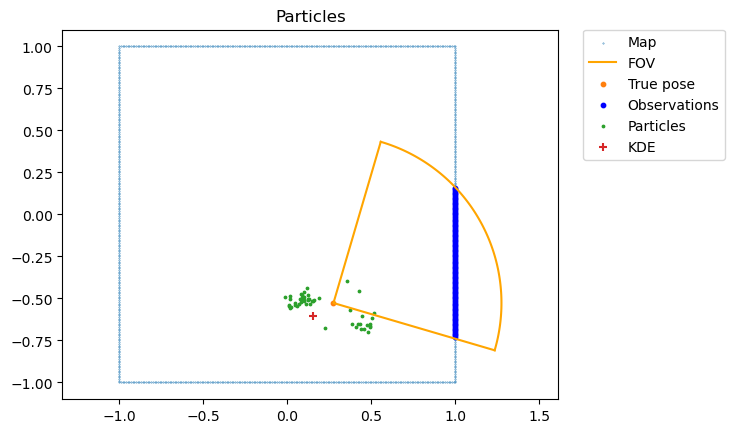

Step 13
Number of effective particles:  42.54295964521659


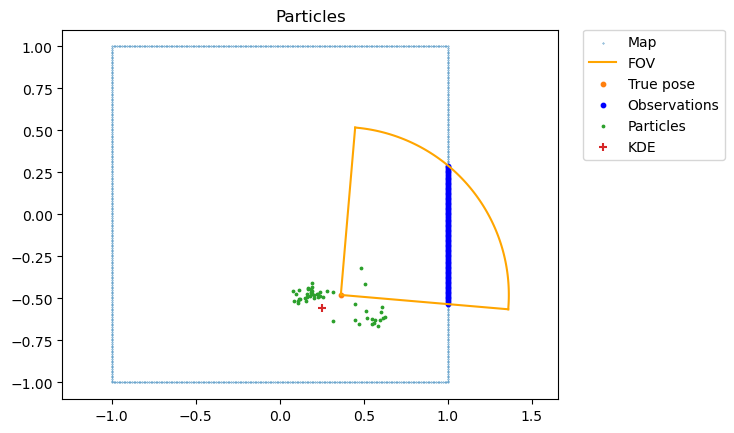

Step 14
Number of effective particles:  41.5528643016365


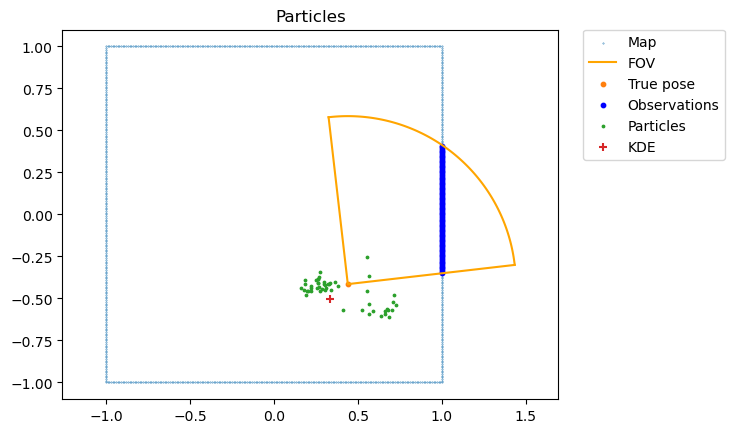

Step 15
Number of effective particles:  40.702078318014095


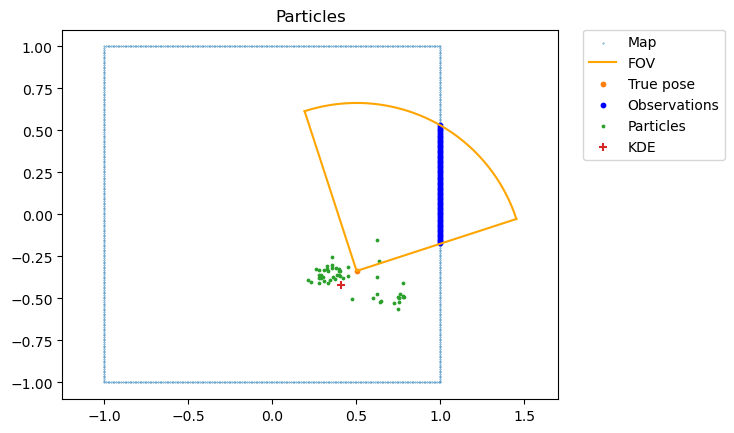

Step 16
Number of effective particles:  39.67006520100927


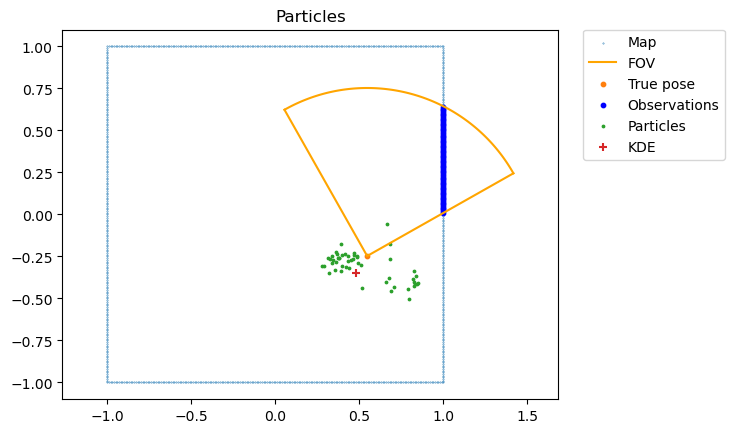

Step 17
Number of effective particles:  38.05760135263684


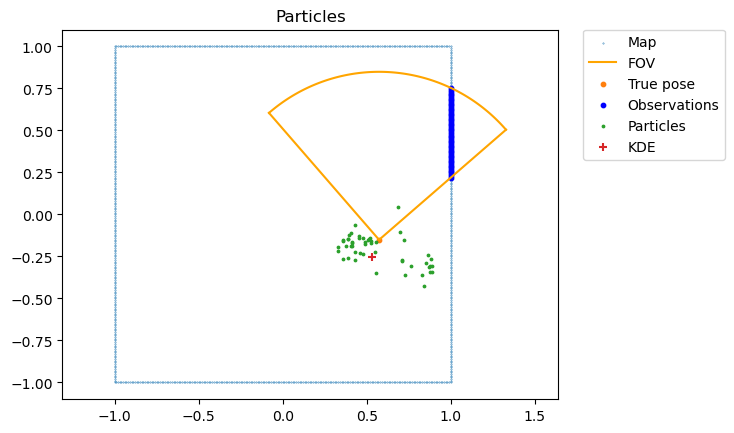

Step 18
Number of effective particles:  38.43450012413612


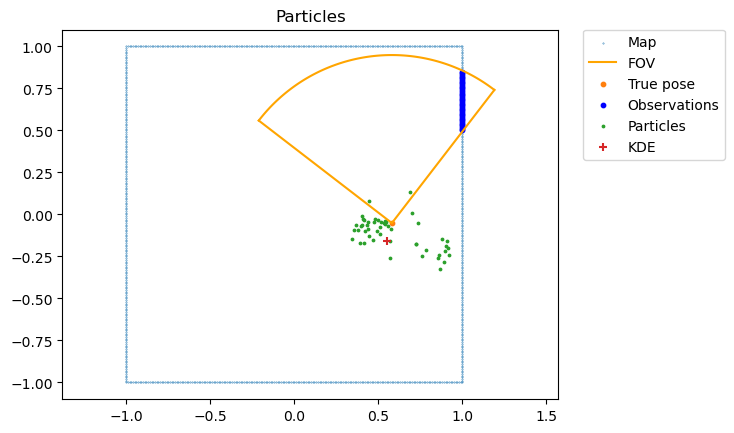

Step 19
Number of effective particles:  36.57476773429596


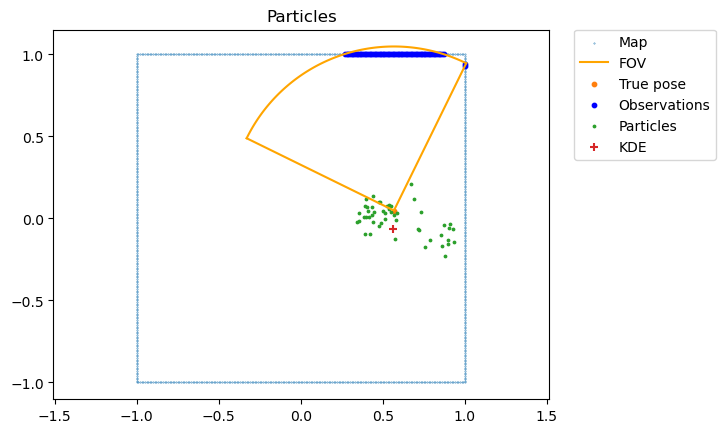

Step 20
Number of effective particles:  36.70932210908522


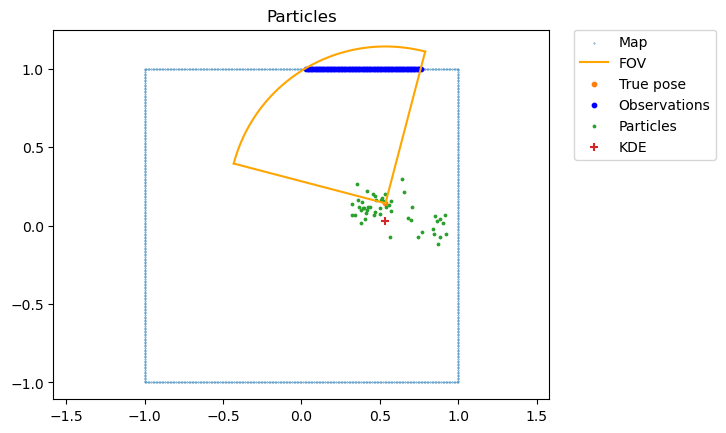

Step 21
Number of effective particles:  35.36355988304531


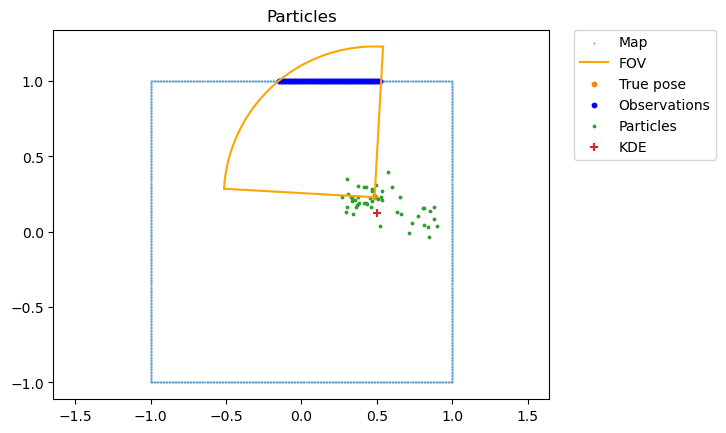

Step 22
Number of effective particles:  34.613809562824336


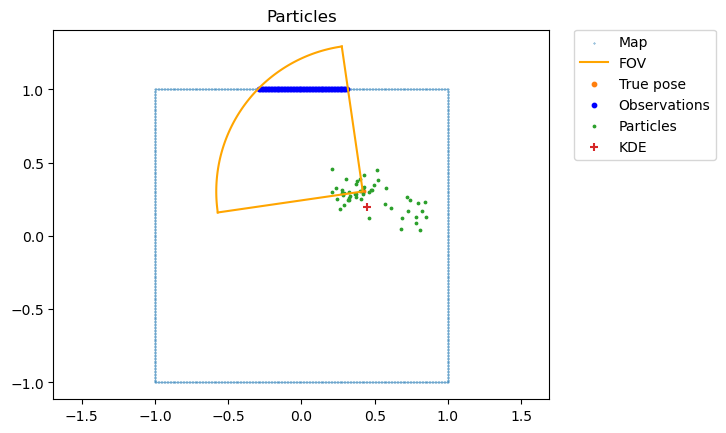

Step 23
Number of effective particles:  34.347682520337436


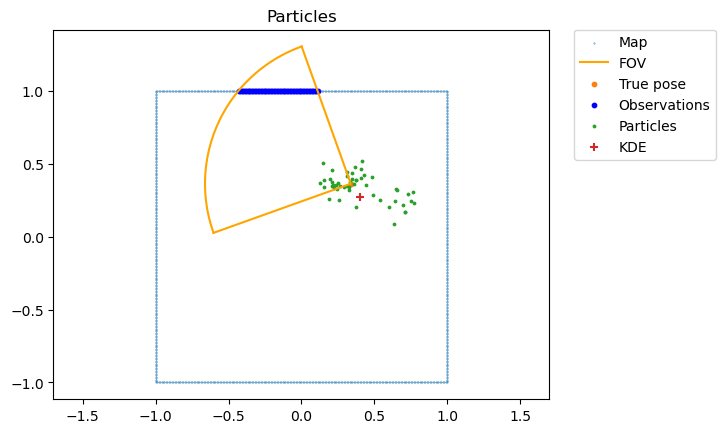

Step 24
Number of effective particles:  34.26375872765451


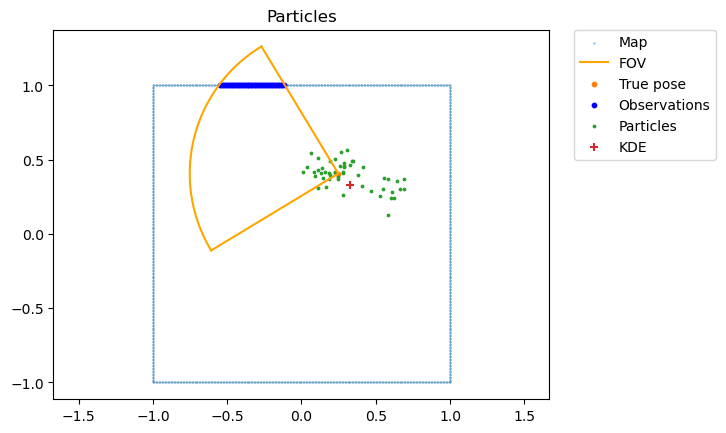

Step 25
Number of effective particles:  33.38764989564206


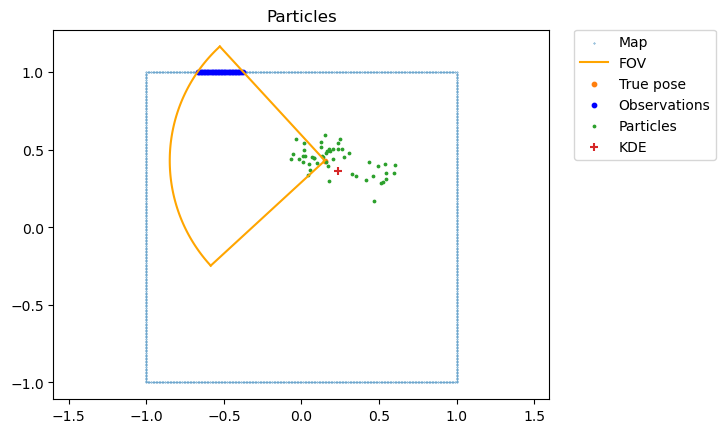

Step 26
Number of effective particles:  31.575978720689747


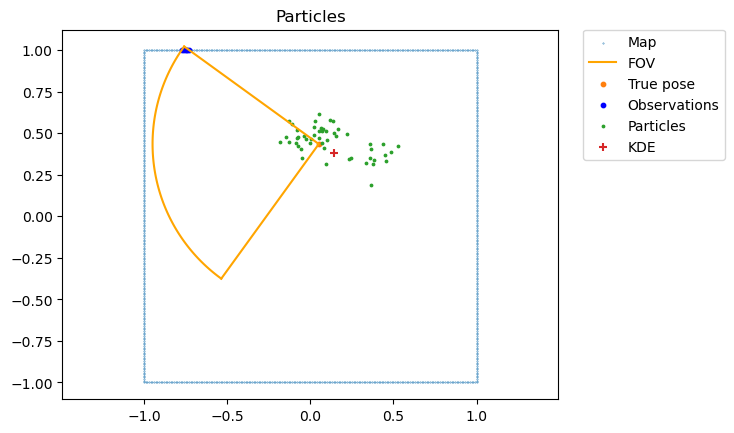

Step 27
Number of effective particles:  24.58327712616849
Resampling


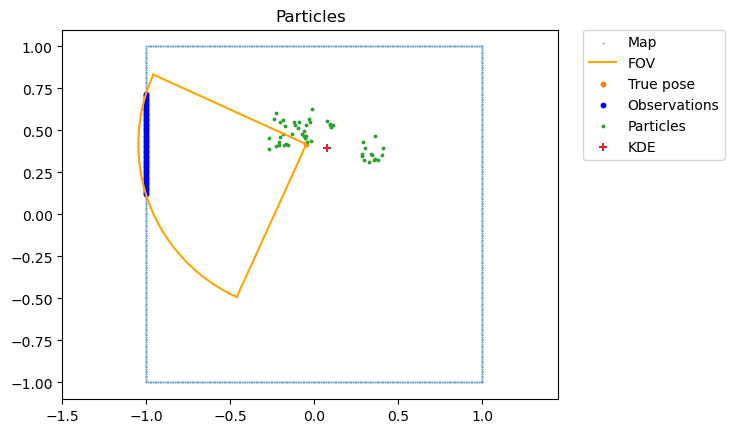

Step 28
Number of effective particles:  37.03287697634214


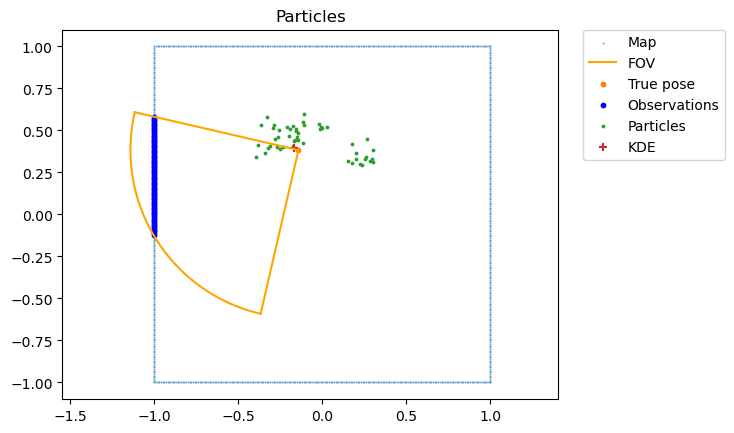

Step 29
Number of effective particles:  32.99194761000233


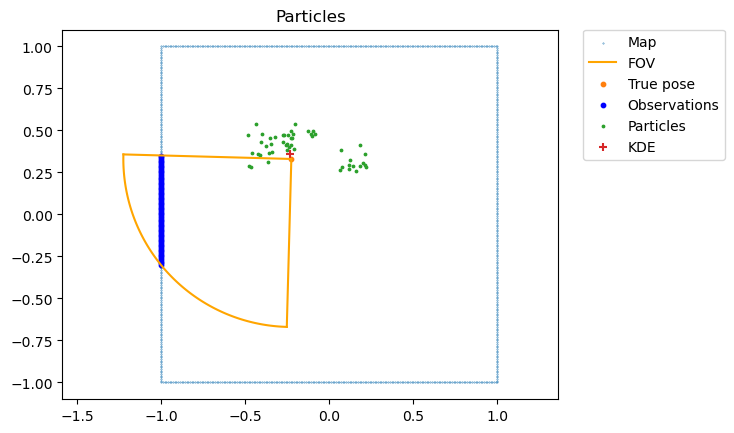

Step 30
Number of effective particles:  3.361153038820044
Resampling


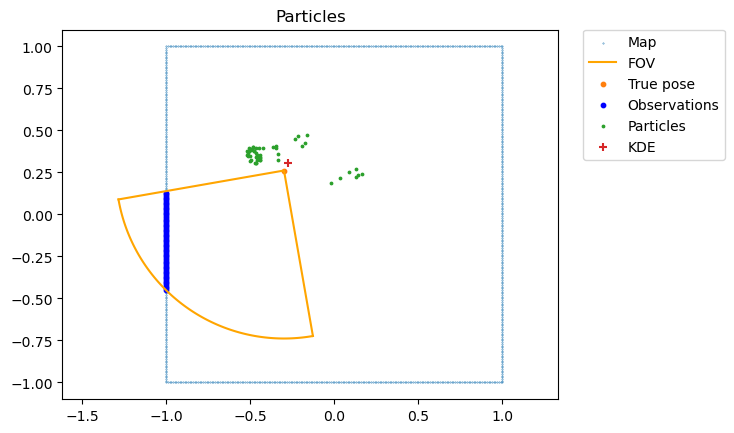

Step 31
Number of effective particles:  29.18947437170182


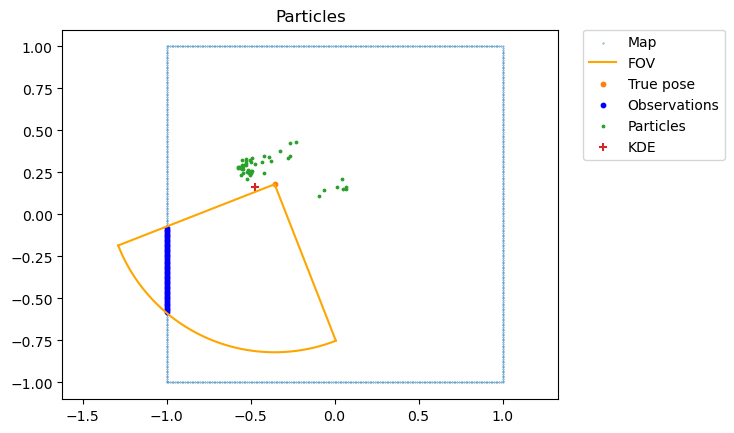

Step 32
Number of effective particles:  29.18913217170965


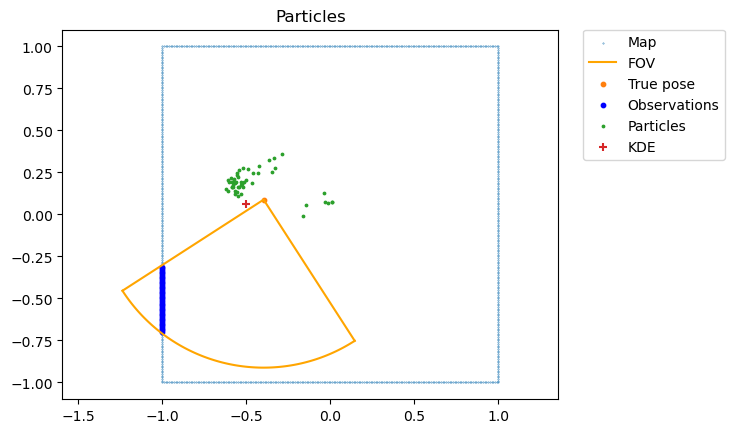

Step 33
Number of effective particles:  29.189132171709584


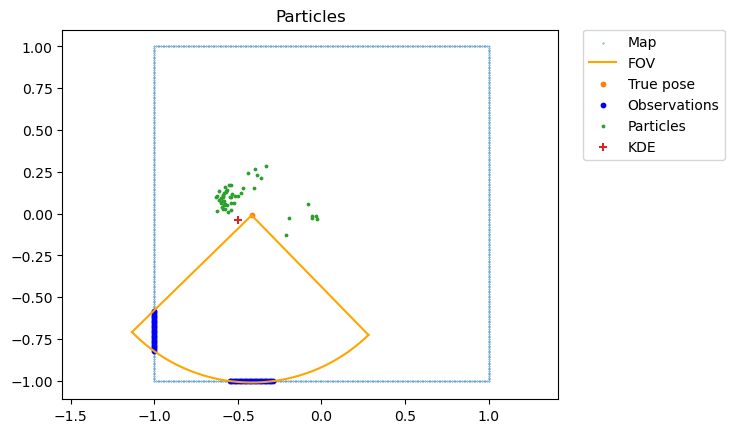

Step 34
Number of effective particles:  29.189132171709574


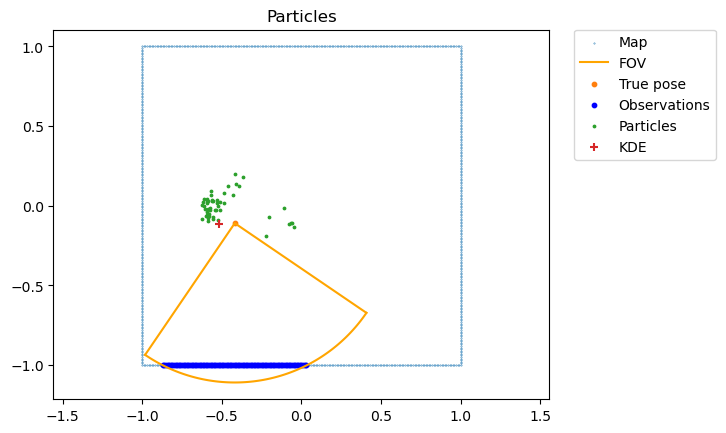

Step 35
Number of effective particles:  29.189132171709574


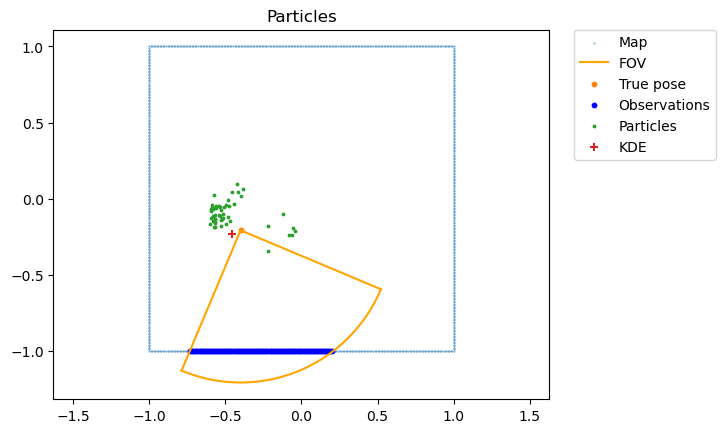

Step 36
Number of effective particles:  29.189132171709574


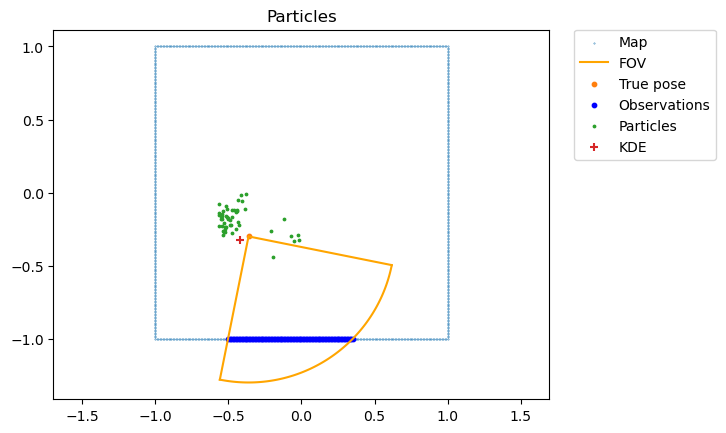

Step 37
Number of effective particles:  29.189132171709574


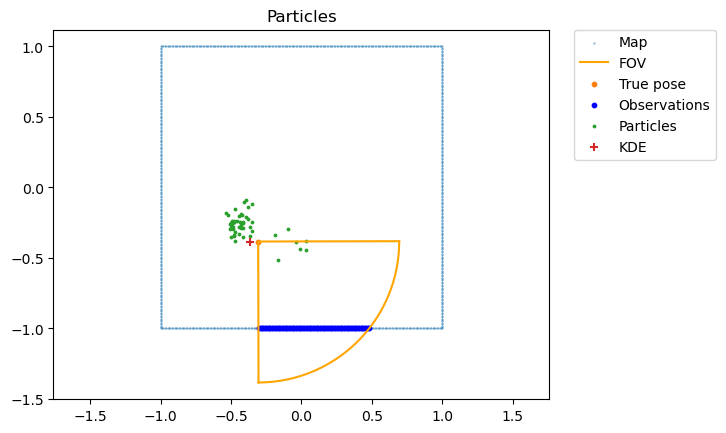

Step 38
Number of effective particles:  29.189132171709574


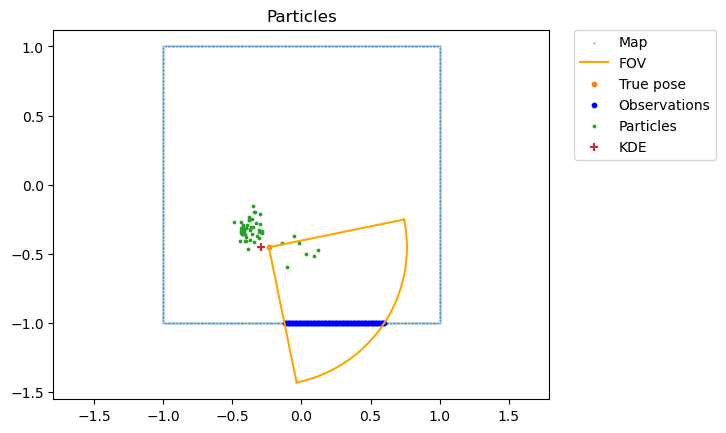

Step 39
Number of effective particles:  29.189132171709574


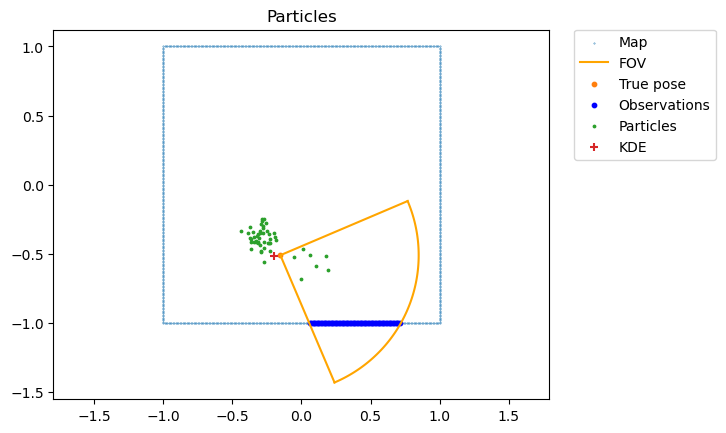

Step 40
Number of effective particles:  29.189132171709574


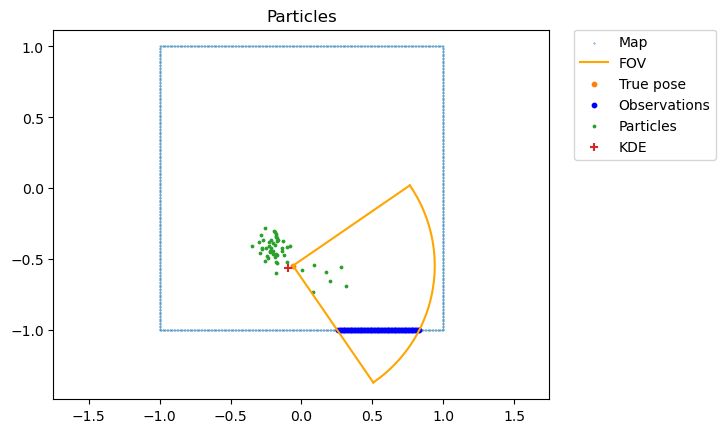

Step 41
Number of effective particles:  3.62482080725183
Resampling


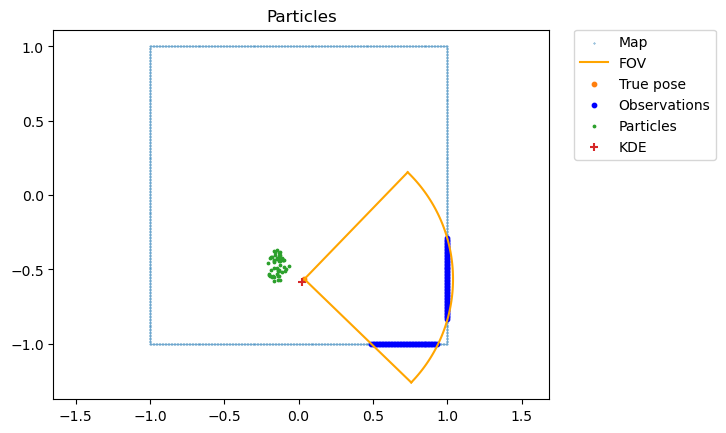

Step 42
Number of effective particles:  48.04618841819829


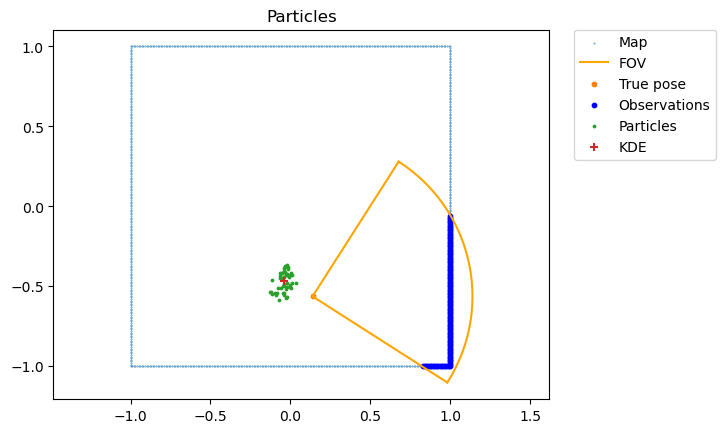

Step 43
Number of effective particles:  46.54462334512394


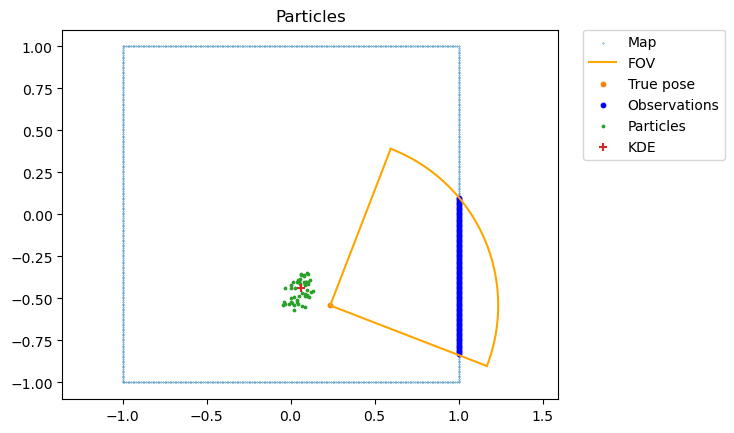

Step 44
Number of effective particles:  44.95789436705552


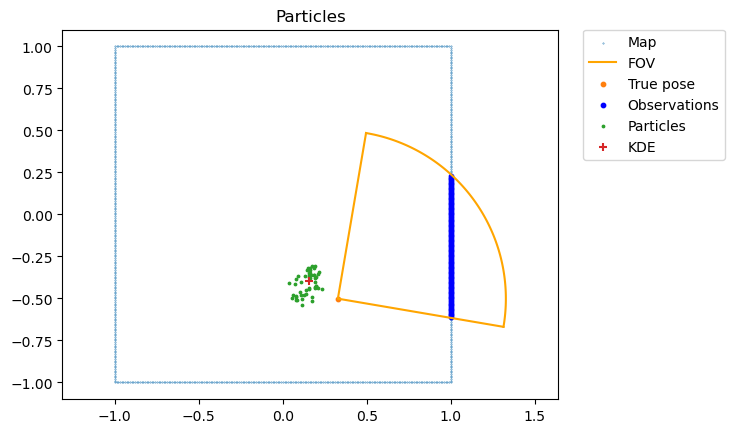

Step 45
Number of effective particles:  42.81794291005965


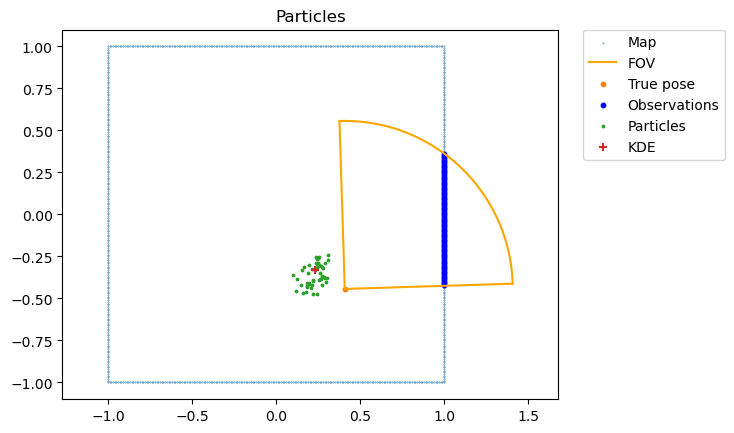

Step 46
Number of effective particles:  41.75029690670103


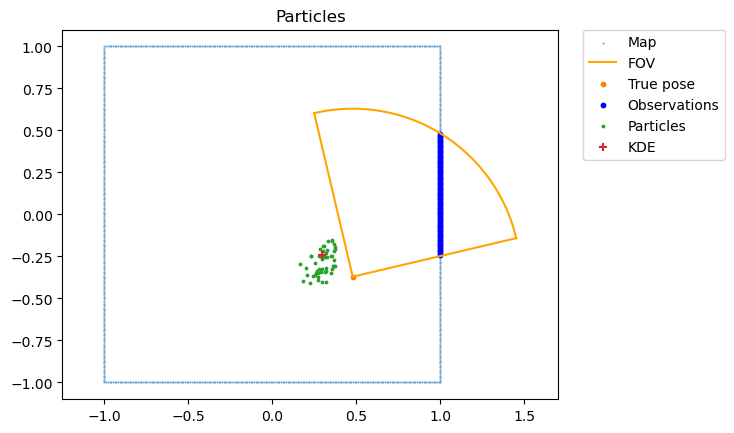

Step 47
Number of effective particles:  38.77286957980709


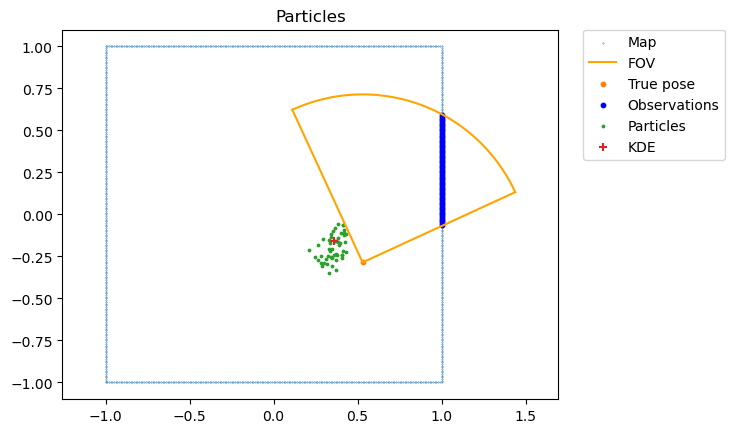

Step 48
Number of effective particles:  33.98595292973918


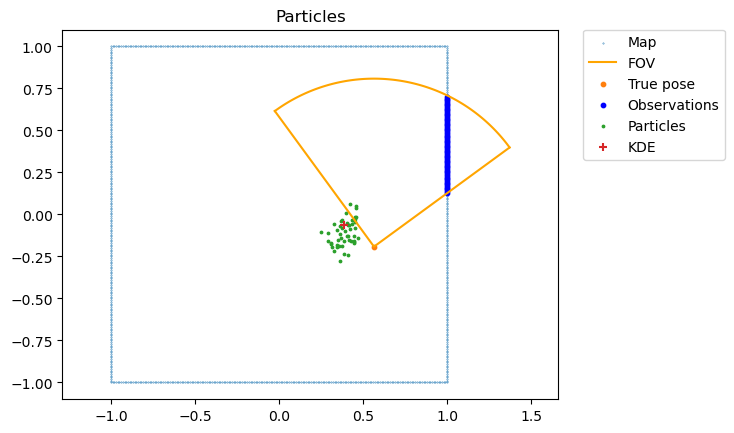

Step 49
Number of effective particles:  28.3111247814999


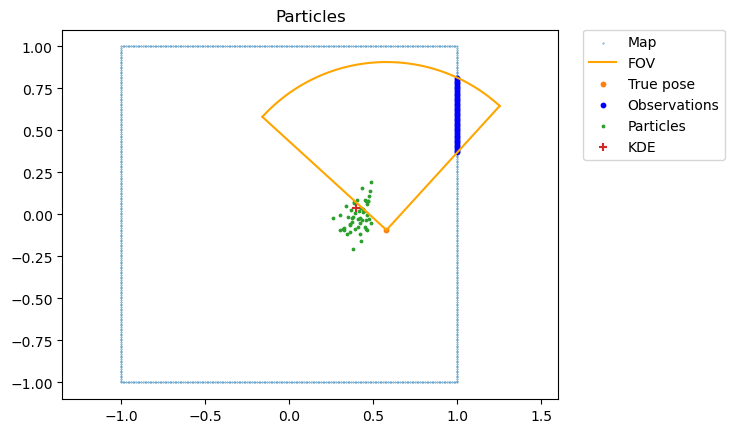

Step 50
Number of effective particles:  27.38132105887014


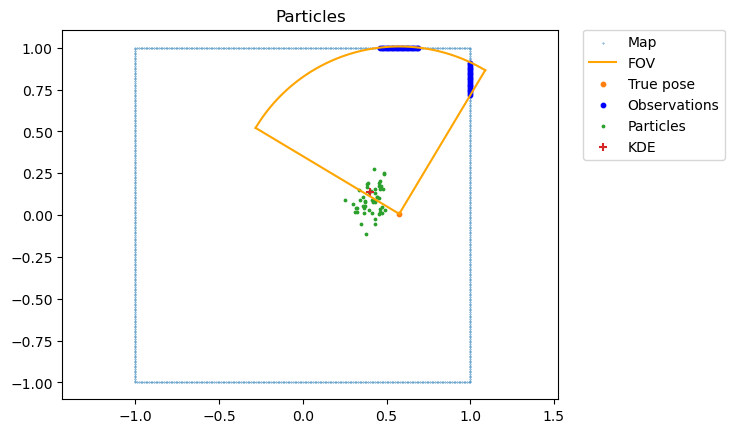

Step 51
Number of effective particles:  26.562217481258106


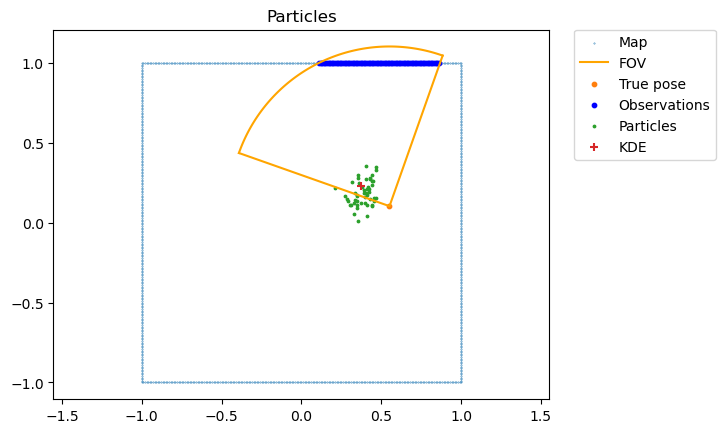

Step 52
Number of effective particles:  25.562306513513654


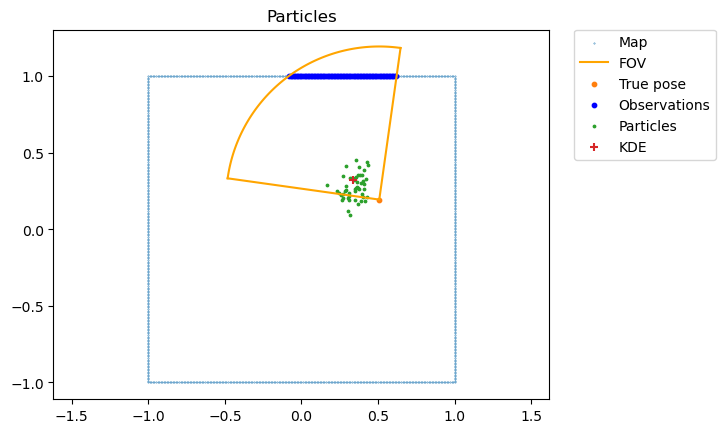

Step 53
Number of effective particles:  22.478009255449216
Resampling


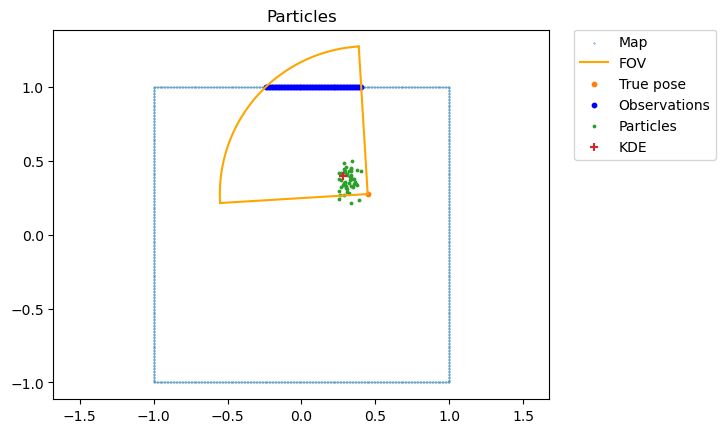

Step 54
Number of effective particles:  37.620829442130486


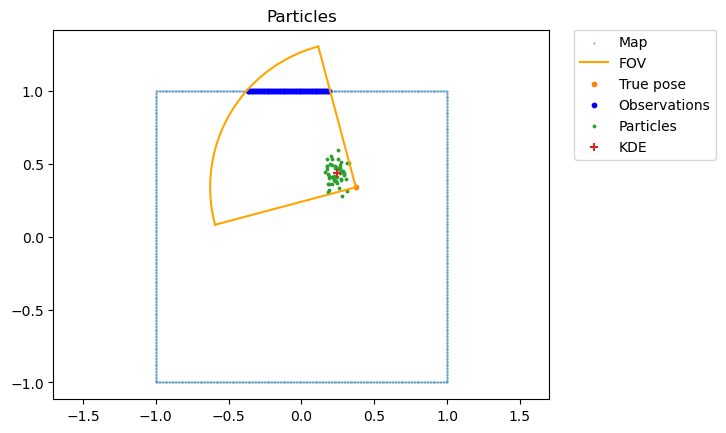

Step 55
Number of effective particles:  33.677494291114954


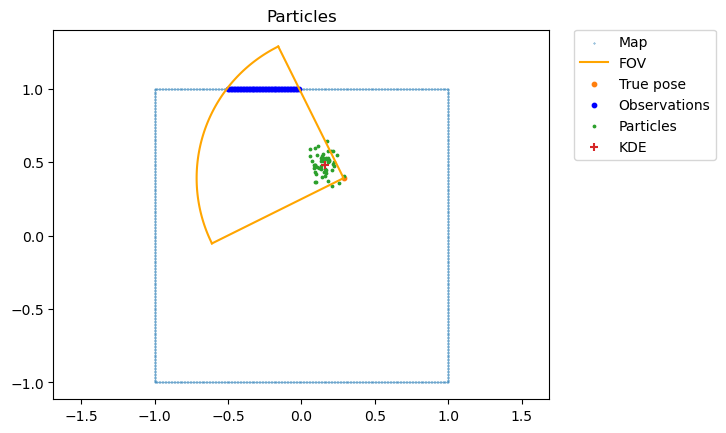

Step 56
Number of effective particles:  27.799177441055505


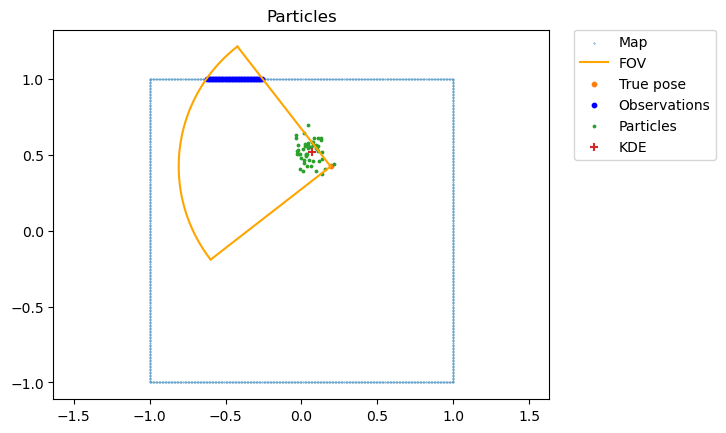

Step 57
Number of effective particles:  23.90738506381546
Resampling


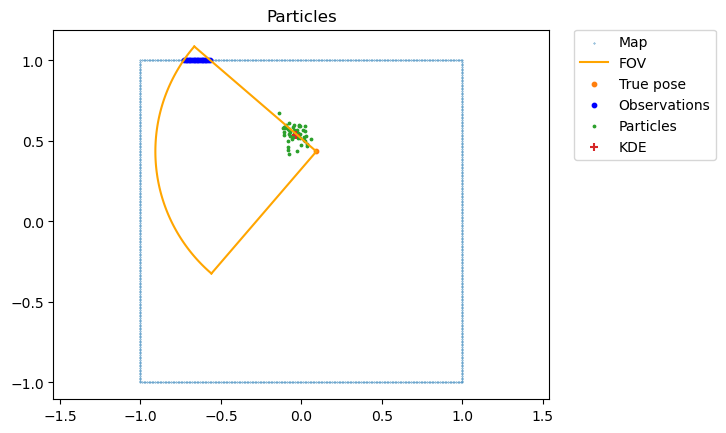

Step 58
Number of effective particles:  36.18924825181728


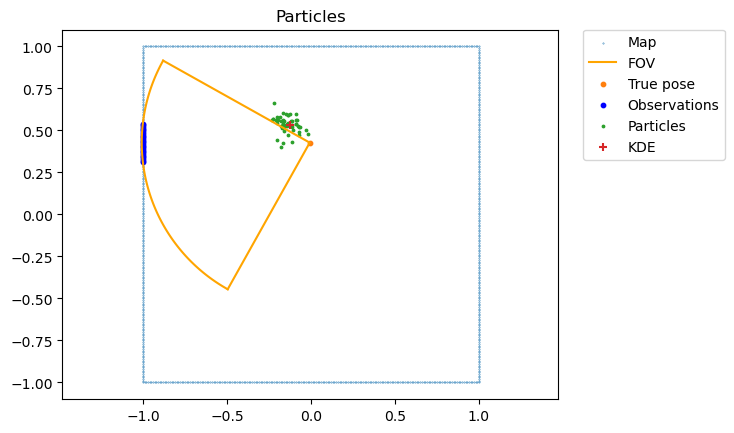

Step 59
Number of effective particles:  32.68051927681638


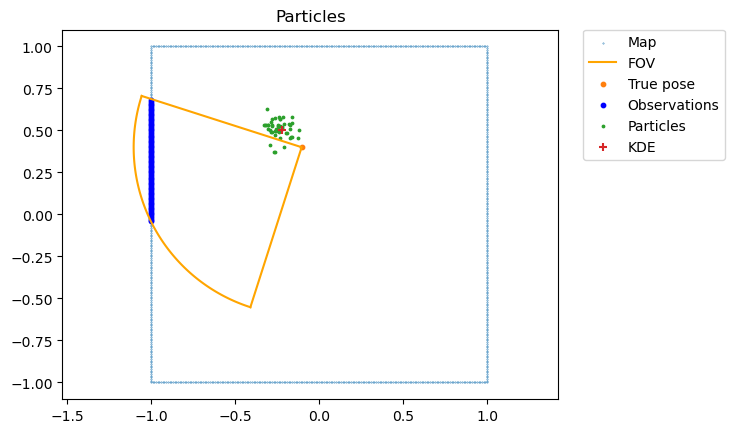

In [3]:
from pygp_particle_filter import ParticleFilter

# robot_pose = np.array([0.0, -0.5, 0.0])

# Create a particle filter
num_particles = 50
x_init=robot_pose[0]
y_init=robot_pose[1]
gamma_init=robot_pose[2]
auxilliary_noise=[0.20, 0.20, 0.05, 0.02, 0.01]
jitter=0.05



particle_filter = ParticleFilter(num_particles, 
                                 x_init, 
                                 y_init, 
                                 gamma_init,
                                 jitter,
                                 auxilliary_noise)

num_steps = 60

# v = w * r
# for a r = 0.5 m and a linear speed of 0.1, w = 0.2
linear_speed = 0.1
angular_speed = 0.2
observation_std = 0.1
length_scale = 0.1

lidar_fov = np.pi / 2
lidar_range_max = 1.0

dt = 1.0
current_time = 0.0
control_input = [0.0, 0.0, 0.0]

#containors to store data
T = []
P_KDE = []
P_STD = []
P_GT = []
observations_all = []


plt.figure()

for i in range(num_steps):
    print('Step {}'.format(i))
    # Timestep 
    current_time += dt
    
    # Update control input
    control_input = np.array([current_time, linear_speed, angular_speed])

    # Predict the next positions
    particle_filter.predict(control_input)
    
    # Move the GT robot too
    robot_pose[0] += control_input[1] * np.cos(robot_pose[2]) * dt
    robot_pose[1] += control_input[1] * np.sin(robot_pose[2]) * dt
    robot_pose[2] += control_input[2] * dt
    robot_pose[2] = robot_pose[2] % (2*np.pi) 
    
    kde_pose, kde_std  = particle_filter.kde_pose(sigma_resolution=0.1, sampling_resolution=1000)
    observations = get_observations(robot_pose, simulation_map, lidar_fov, lidar_range_max)

    ## Run update 
    particle_filter.observation_update(observations,  observation_std, length_scale)

    ## PLOTTING
    # Get the particles for plotting
    particles_x = [p.x for p in particle_filter.particles]
    particles_y = [p.y for p in particle_filter.particles]
    # Plot the FOV
    fov_points = np.array(
        [
            [lidar_range_max * np.cos(lidar_fov / 2 + robot_pose[2]), 
             lidar_range_max * np.sin(lidar_fov / 2 + robot_pose[2])],
            [0, 0],
            [lidar_range_max * np.cos(-lidar_fov / 2 + robot_pose[2]), 
             lidar_range_max * np.sin(-lidar_fov / 2 + robot_pose[2])],
        ]
    )
    fov_points = fov_points + robot_pose[0:2]
    # Add a semicircle
    t = np.linspace(- lidar_fov / 2 + robot_pose[2], lidar_fov / 2 + robot_pose[2], 100)
    x = lidar_range_max * np.cos(t) + robot_pose[0]
    y = lidar_range_max * np.sin(t) + robot_pose[1]
    # Plot the particles
    plt.clf()
    plt.scatter(simulation_map[:, 0], simulation_map[:, 1], s=0.1, label='Map')
    plt.plot(x, y, c="orange")
    plt.plot(fov_points[:, 0], fov_points[:, 1], c="orange", label="FOV")
    plt.scatter(robot_pose[0], robot_pose[1], s=10, label='True pose')
    plt.scatter(robot_pose[0] + observations[:, 0] * np.cos(observations[:, 1] + robot_pose[2]),
                robot_pose[1] + observations[:, 0] * np.sin(observations[:, 1] + robot_pose[2]), c="blue", s=10, label='Observations')
    plt.scatter(particles_x, particles_y, s=3, label='Particles')
    plt.scatter(kde_pose[0], kde_pose[1], s=30, marker='+', label='KDE')    
    
    plt.axis('equal')
    plt.title('Particles')
    # Place legend outside the plot
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    plt.show()

    #store
    T.append(current_time)
    P_KDE.append(kde_pose.tolist())     # or list(kde_pose)
    P_STD.append(kde_std.tolist())
    P_GT.append(robot_pose.copy())      # if robot_pose is a NumPy array
    observations_all.append(observations.copy())  # if needed

# After the loop, convert to arrays
T = np.array(T)
P_KDE = np.array(P_KDE)
P_STD = np.array(P_STD)
P_GT = np.array(P_GT)

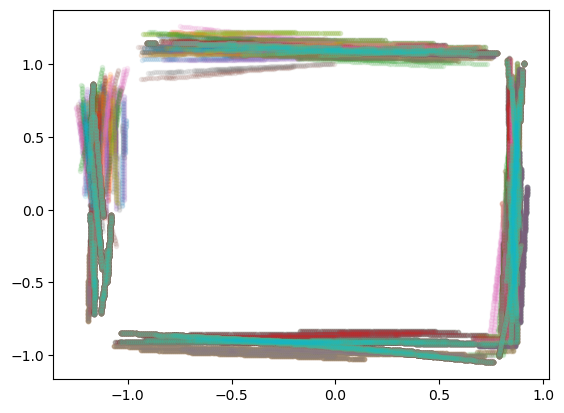

In [7]:
# Plot one particle observation map

plt.figure()
for p in particle_filter.particles:
    obs = p.observations
    plt.plot(obs[:, 0], obs[:, 1], '.', alpha=0.1)
    
plt.show()


In [8]:
def show_scan(pose, observations, ax):
    
    # Robot pose
    robot_x, robot_y = pose[0], pose[1]
    ax.scatter(robot_x, robot_y, color='red')

    # Observations
    for obs in observations:
        r, theta = obs
        x, y = r * np.cos(theta+pose[2]), r * np.sin(theta+pose[2])
        ax.scatter(robot_x + x, robot_y + y, color='blue')

Ground truth path and observations


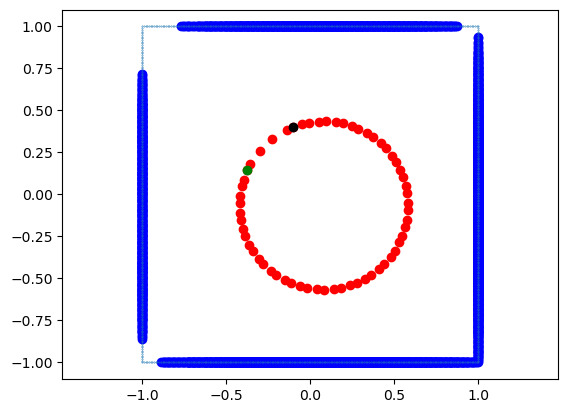

Particle Path SLAM KDE


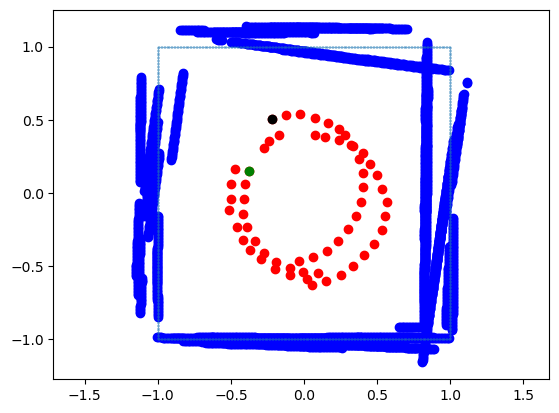

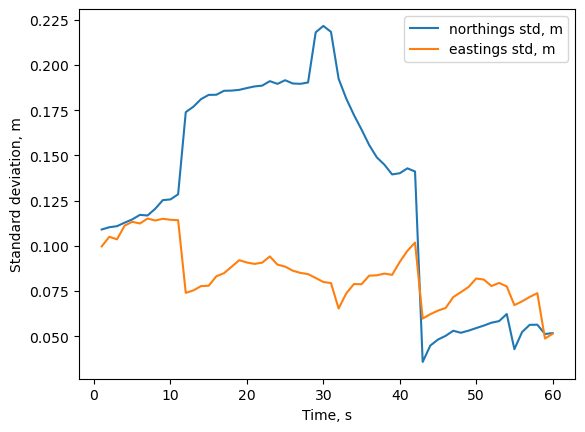

In [9]:
fig,ax = plt.subplots()

print('Ground truth path and observations')
for i in range(len(P_GT)):
    p = P_GT[[i],0:3].T        
    show_scan(p, observations_all[i],ax)

plt.scatter(simulation_map[:, 0], simulation_map[:, 1], s=0.1)
plt.scatter(P_GT[[0],0], P_GT[[0],1], c='g')
plt.scatter(P_GT[[-1],0], P_GT[[-1],1], c='k')
plt.axis('equal')
plt.show()

fig,ax = plt.subplots()
print('Particle Path SLAM KDE')
for i in range(len(P_GT)):
    p = P_KDE[[i],0:3].T    
    show_scan(p, observations_all[i], ax)

plt.scatter(simulation_map[:, 0], simulation_map[:, 1], s=0.1)
plt.scatter(P_KDE[[0],0], P_KDE[[0],1], c='g')
plt.scatter(P_KDE[[-1],0], P_KDE[[-1],1], c='k')
plt.axis('equal')
plt.show()    

plt.plot(T,P_STD[:,0], label = 'northings std, m')
plt.plot(T,P_STD[:,1], label = 'eastings std, m')
plt.xlabel('Time, s')
plt.ylabel('Standard deviation, m')
plt.legend()
plt.show()    